## CONTEXTO

**Barreras a la Formación (EAL-24)** y **Motivos de No Formación (EAL-25)**

### Resumen de Tablas: Análisis de Barreras y Limitaciones

| Código de Tabla | Descripción del Contenido | Relevancia para el Proyecto |
| :--- | :--- | :--- |
| **EAL-24** | **Barreras Generales:** Grado de limitación (nada a mucho) de 10 motivos específicos en empresas que **SÍ** proporcionaron formación. | Proporciona la línea base nacional para entender qué dificultades encuentran las empresas al intentar formar. |
| **EAL-24c** | **Barreras en Grandes Empresas:** Mismo desglose que la EAL-24 pero exclusivo para empresas de **más de 499 trabajadores**. | **Es la tabla prioritaria.** Al ser RapidExpress una gran empresa, estos datos reflejan sus retos específicos (ej. carga de trabajo). |
| **EAL-24f** | **Barreras en el Sector Servicios:** Limitaciones detectadas específicamente en las empresas de servicios que sí forman. | Permite contrastar si las barreras de nuestro sector (Transporte) son más agudas que en el resto de servicios. |
| **EAL-25** | **Motivos de No Formación:** Grado de influencia de factores que llevaron a la decisión de **NO** proporcionar formación. | Útil para identificar por qué otras empresas del mercado deciden no invertir en el desarrollo de su personal. |
| **EAL-25b** | **Inacción en Medianas/Grandes Empresas:** Motivos de no formación en empresas de **50 o más trabajadores**. | Se utiliza como **referencia (proxy)** para entender las razones estratégicas o logísticas de inacción en organizaciones de mayor tamaño. |
| **EAL-25e** | **No Formación en Servicios:** Razones de peso por las que el sector servicios decide no realizar acciones formativas. | Ayuda a diagnosticar si en nuestro entorno la falta de formación se debe a una "decisión estratégica" o a "barreras reales". |


**Nota Metodológica:** Todas las comparaciones entre porcentajes de estas tablas (especialmente entre **EAL-24c** y el resto) serán validadas mediante **tests de diferencias de proporciones (Z-test)** para asegurar que los hallazgos sean estadísticamente significativos

## 1. Fase de EDA y Consistencia (Dataset 2020-2024)
*   **Mantenimiento del Top-2-Box:** Utilizaremos la columna **RELEVANCIA** (Bastante + Mucho) para simplificar la comparación.
*   **Tratamiento de Inconsistencias (Mapeo):** Dado que el número de respuestas cambió entre 2020 y 2021, antes de filtrar aseguramos que las categorías de barreras sean las mismas en toda la serie 

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

In [111]:
df_barreras= pd.read_csv('../../Data/clean/EAL_15062025/limitaciones.csv')

In [112]:
df_barreras

,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO
0,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,10.031,13.505,60.232,16.232
1,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La estrategia preferida de la empresa fue cont...,32.843,22.364,35.637,9.155
2,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,37.356,45.367,15.583,1.694
3,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,31.751,39.726,21.844,6.679
4,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,24.188,36.048,29.953,9.811
...,...,...,...,...,...,...,...,...,...
277,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La empresa prefirió tener personal con contrat...,70.067,19.881,8.260,1.792
278,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,El mayor esfuerzo realizado en años anteriores...,44.018,34.269,17.211,4.502
279,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La elevada carga de trabajo y el escaso tiempo...,22.419,29.643,30.416,17.522
280,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,Dificultad para acceder a ayudas o subvencione...,36.200,30.566,20.535,12.699


In [113]:
df_barreras.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   anio                      282 non-null    int64  
 1   tabla                     282 non-null    object 
 2   proporcionaron_formacion  282 non-null    object 
 3   pregunta                  282 non-null    object 
 4   ambito                    282 non-null    object 
 5   NADA                      282 non-null    float64
 6   POCO                      282 non-null    float64
 7   BASTANTE                  282 non-null    float64
 8   MUCHO                     282 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 20.0+ KB


In [114]:
df_barreras.shape

(282, 9)

In [115]:
df_barreras.describe().round(2)

,anio,NADA,POCO,BASTANTE,MUCHO
count,282.00,282.00,282.00,282.00,282.00
mean,2022.10,31.23,33.82,26.01,8.94
std,1.39,15.81,11.44,13.12,6.89
min,2020.00,6.46,6.87,4.22,0.17
25%,2021.00,20.32,25.87,16.90,3.19
50%,2022.00,28.56,34.36,23.23,7.00
75%,2023.00,37.28,42.39,34.99,12.51
max,2024.00,72.63,58.05,61.08,33.58


La mayoría de las barreras son percibidas como poco o nada importantes, aunque algunas destacan claramente sobre el resto y llegan a ser consideradas obstáculos relevantes por una proporción significativa de empresas.

In [116]:
df_barreras.columns

Index(['anio', 'tabla', 'proporcionaron_formacion', 'pregunta', 'ambito',
       'NADA', 'POCO', 'BASTANTE', 'MUCHO'],
      dtype='object')

### **Distribución de frecuencias:** 

Generamos tablas de frecuencias para las respuestas "Bastante" y "Mucho" de las tablas **EAL-24c** (>499 trabajadores) y **EAL-25b** (>=50 trabajadores).

Primero creamos columna RELEVANCIA

In [117]:
df_relevancia=df_barreras.copy()

In [118]:
df_relevancia

,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO
0,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,10.031,13.505,60.232,16.232
1,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La estrategia preferida de la empresa fue cont...,32.843,22.364,35.637,9.155
2,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,37.356,45.367,15.583,1.694
3,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,31.751,39.726,21.844,6.679
4,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,24.188,36.048,29.953,9.811
...,...,...,...,...,...,...,...,...,...
277,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La empresa prefirió tener personal con contrat...,70.067,19.881,8.260,1.792
278,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,El mayor esfuerzo realizado en años anteriores...,44.018,34.269,17.211,4.502
279,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La elevada carga de trabajo y el escaso tiempo...,22.419,29.643,30.416,17.522
280,2024,EAL-25e,No,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,Dificultad para acceder a ayudas o subvencione...,36.200,30.566,20.535,12.699


Creamos un diccionario de barreras para facilitar la lectura de conceptos

In [119]:
mapa_nombres = {
    # --- 1. Contratación Capacitada  ---
    "La empresa prefirió contratar a personal con la cualificación, habilidades y competencias necesarias": "Nueva contratación capacitada",
    "La estrategia preferida de la empresa fue contratar personal con la cualificación, habilidades o competencias requeridas": "Nueva contratación capacitada",

    # --- 2. Formación Dual / Contratos ---
    "La empresa prefirió tener personal con contratos formativos o personal en formación por convenio de Formación profesional dual a proporcionar más formación a sus trabajadores": "Contratos formación/Dual",
    "La empresa prefirió tener personal con contrato de formación y aprendizaje o formación por convenio de formación profesional dual": "Contratos formación/Dual",
    "La empresa prefirió tener personal con contratos formativos": "Contratos formación/Dual",

    # --- 3. Carga de Trabajo  ---
    "La elevada carga de trabajo y el escaso tiempo disponible de los empleados de su empresa": "Carga trabajo / Falta tiempo",
    "La elevada carga de trabajo y el escaso tiempo disponible de los trabajadores de la empresa": "Carga trabajo / Falta tiempo",

    # --- 4. Nivel Formativo ---
    "El nivel de formación de los empleados era el apropiado para las necesidades de la empresa": "Nivel formación adecuado",
    "El nivel de cualificación, habilidades y competencias de los trabajadores era el adecuado para las necesidades de la empresa": "Nivel formación adecuado",

    # --- 5. Otras Razones ---
    "Otras razones": "Otras razones",

    # --- Resto de barreras (Estructura constante 2020-2024) ---
    "Cancelación o aplazamiento de las actividades de formación debido a las restricciones por COVID": "Restricciones COVID",
    "El alto coste de los cursos de formación": "Alto coste cursos",
    "Dificultad para acceder a ayudas o subvenciones públicas": "Dificultad ayudas públicas",
    "La falta de cursos de formación adecuados en el mercado": "Falta oferta adecuada",
    "El mayor esfuerzo realizado en años anteriores para ofrecer formación a sus trabajadores": "Esfuerzo años anteriores",
    "Dificultad para evaluar la necesidades de formación de la empresa": "Dificultad evaluar necesidades"
}

# 2. Aplicación con limpieza de espacios (TRIM) para evitar fallos de lectura
df_relevancia['ambito_corto'] = df_relevancia['ambito'].str.strip().map(mapa_nombres)

# 3. Verificación de limpieza
nan_count = df_relevancia['ambito_corto'].isna().sum()
if nan_count == 0:
    print("¡Conseguido! Todas las filas están mapeadas correctamente.")
else:
    print(f"Aún quedan {nan_count} filas sin mapear.")
    print(df_relevancia[df_relevancia['ambito_corto'].isna()]['ambito'].unique())

¡Conseguido! Todas las filas están mapeadas correctamente.


In [120]:
# Creamos el índice de RELEVANCIA (Top-2-Box)
df_relevancia['RELEVANCIA'] = df_relevancia['BASTANTE'] + df_relevancia['MUCHO']

# Visualización rápida de la estructura
print(f"Dataset cargado: {df_relevancia.shape} filas.")
df_relevancia.head()


Dataset cargado: (282, 11) filas.


,anio,tabla,proporcionaron_formacion,pregunta,ambito,NADA,POCO,BASTANTE,MUCHO,ambito_corto,RELEVANCIA
0,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El nivel de formación de los empleados era el ...,10.031,13.505,60.232,16.232,Nivel formación adecuado,76.464
1,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La estrategia preferida de la empresa fue cont...,32.843,22.364,35.637,9.155,Nueva contratación capacitada,44.792
2,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,Dificultad para evaluar la necesidades de form...,37.356,45.367,15.583,1.694,Dificultad evaluar necesidades,17.277
3,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,La falta de cursos de formación adecuados en e...,31.751,39.726,21.844,6.679,Falta oferta adecuada,28.523
4,2020,EAL-24,Si,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,El alto coste de los cursos de formación,24.188,36.048,29.953,9.811,Alto coste cursos,39.764


> Se aplicó la técnica **Top-2-Box**, que consiste en agrupar las respuestas **"Bastante"** y **"Mucho"** en un único indicador de **relevancia**. Esta transformación simplifica la interpretación de los resultados, facilita la elaboración de rankings y permite identificar rápidamente las barreras, competencias o necesidades formativas más importantes para las empresas. Además, mejora la comparabilidad entre sectores y hace más clara la visualización de los hallazgos para la toma de decisiones, convirtiéndose en un indicador clave para priorizar las acciones de RRHH.

#### Barreras grandes empresas formadoras (EAL-24c)

In [121]:
# 1. Empresas de >499 que SÍ proporcionaron formación (EAL-24c)
print("--- RELEVANCIA DE BARRERAS EN GRANDES EMPRESAS (>499) ---")
resumen_24c = df_relevancia[df_relevancia['tabla'] == 'EAL-24c'][['ambito_corto', 'RELEVANCIA', 'BASTANTE', 'MUCHO']].sort_values(by='RELEVANCIA', ascending=False)
print(resumen_24c)

--- RELEVANCIA DE BARRERAS EN GRANDES EMPRESAS (>499) ---
                       ambito_corto  RELEVANCIA  BASTANTE   MUCHO
62     Carga trabajo / Falta tiempo      55.277    42.644  12.633
119    Carga trabajo / Falta tiempo      55.056    41.209  13.847
82         Nivel formación adecuado      54.260    47.241   7.019
38     Carga trabajo / Falta tiempo      53.886    44.092   9.794
112        Nivel formación adecuado      53.291    47.697   5.594
89     Carga trabajo / Falta tiempo      50.298    38.271  12.027
56         Nivel formación adecuado      50.201    44.575   5.626
32         Nivel formación adecuado      49.110    44.621   4.489
14     Carga trabajo / Falta tiempo      46.454    36.550   9.904
8          Nivel formación adecuado      45.687    40.575   5.112
113   Nueva contratación capacitada      37.747    31.742   6.005
83    Nueva contratación capacitada      37.620    31.607   6.013
116               Alto coste cursos      37.570    30.667   6.903
57    Nueva contra

#### Barreras empresas no formadoras (EAL-25b)

In [122]:
# 2. Empresas de >=50 que NO proporcionaron formación (EAL-25b)
print("\n--- RELEVANCIA DE MOTIVOS PARA NO FORMAR (>=50 emp.) ---")
resumen_25b = df_relevancia[df_relevancia['tabla'] == 'EAL-25b'][['ambito_corto', 'RELEVANCIA', 'BASTANTE', 'MUCHO']].sort_values(by='RELEVANCIA', ascending=False)
print(resumen_25b)


--- RELEVANCIA DE MOTIVOS PARA NO FORMAR (>=50 emp.) ---
                       ambito_corto  RELEVANCIA  BASTANTE   MUCHO
232        Nivel formación adecuado      75.057    46.107  28.950
200        Nivel formación adecuado      74.792    56.511  18.281
262        Nivel formación adecuado      73.978    49.030  24.948
140        Nivel formación adecuado      67.250    44.806  22.444
167        Nivel formación adecuado      66.109    45.158  20.951
263   Nueva contratación capacitada      62.547    41.856  20.691
201   Nueva contratación capacitada      58.864    41.861  17.003
233   Nueva contratación capacitada      54.353    35.177  19.176
168   Nueva contratación capacitada      52.749    36.933  15.816
239    Carga trabajo / Falta tiempo      51.655    34.545  17.110
207    Carga trabajo / Falta tiempo      47.768    36.991  10.777
174    Carga trabajo / Falta tiempo      47.460    38.846   8.614
141   Nueva contratación capacitada      43.771    27.328  16.443
146    Carga traba

#### **Visualizaciones de barras iniciales:** 

Creamos diagramas de barras para identificar visualmente cuál es la barrera predominante.


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42355/3192984673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=resumen_24c, x='RELEVANCIA', y='ambito_corto', palette='viridis')


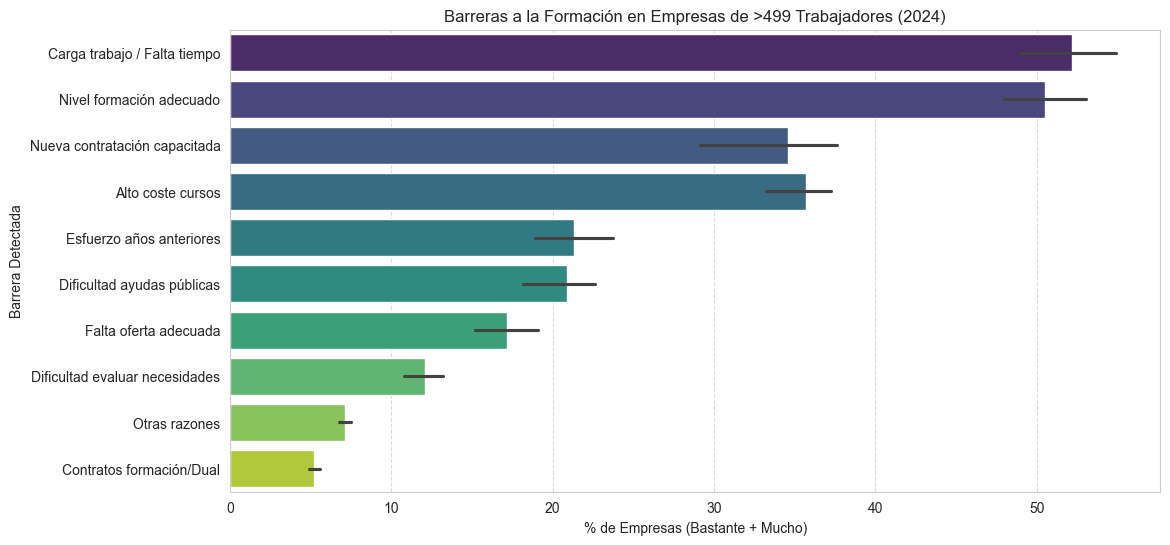

In [123]:
plt.figure(figsize=(12, 6), facecolor='none')
ax=sns.barplot(data=resumen_24c, x='RELEVANCIA', y='ambito_corto', palette='viridis')
ax.set_facecolor('none')
plt.title('Barreras a la Formación en Empresas de >499 Trabajadores (2024)')
plt.xlabel('% de Empresas (Bastante + Mucho)')
plt.ylabel('Barrera Detectada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Confirmamos visualmente que la "elevada carga de trabajo y escaso tiempo" es el factor crítico en las grandes organizaciones que si dieron formación. Casi a la par, se el "nivel de formación apropiado a las necesidades" es otra barrera importante que encontraban las empresas formadoras.

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42355/1790641674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=resumen_25b, x='RELEVANCIA', y='ambito_corto', palette='viridis')


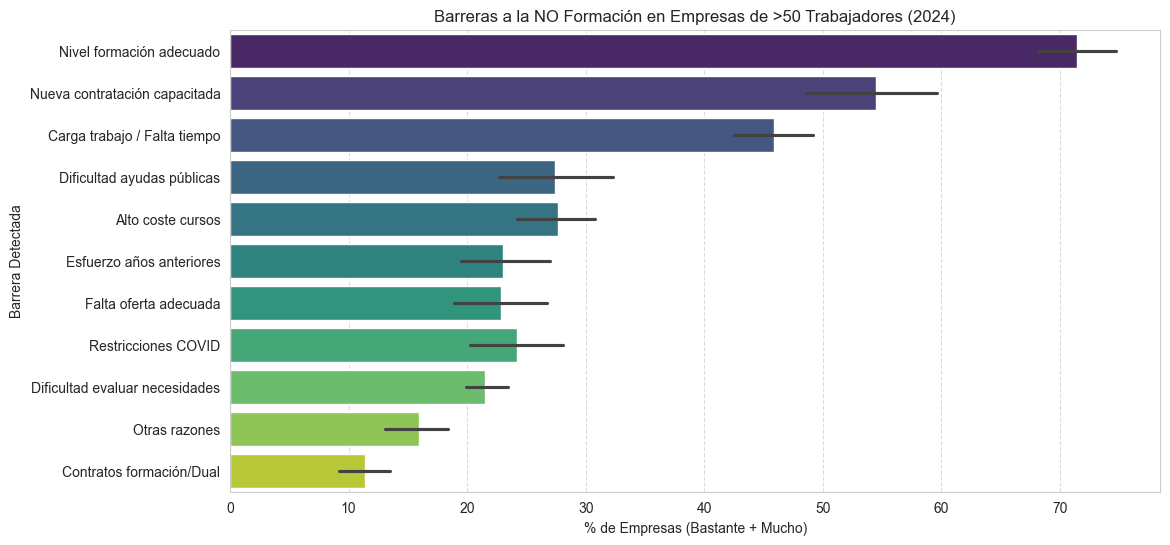

In [124]:
plt.figure(figsize=(12, 6), facecolor='none')
ax=sns.barplot(data=resumen_25b, x='RELEVANCIA', y='ambito_corto', palette='viridis')
ax.set_facecolor('none')
plt.title('Barreras a la NO Formación en Empresas de >50 Trabajadores (2024)')
plt.xlabel('% de Empresas (Bastante + Mucho)')
plt.ylabel('Barrera Detectada')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Motivos de inacción:

Las organizaciones que no dieron formación consideran como factor critico el "nivel de formación apropiado a las necesidades" (auto-suficiencia percibida) junto con la decisión de "contratar a personal cualificado" (nueva contratación capacitada) en lugar de desarrollar talento interno

## 2. Agregación y Clasificación Estratégica (Dimensiones)
10 motivos en las tres macro-categorías definidas en la justificación técnica. Obtendremos una **huella sectorial**:
*   **Factores de Tiempo/Organizativos:** (Motivos 8, 1 y 2). Es crítico observar si la "carga de trabajo" ha sido siempre la barrera número uno o si es un fenómeno reciente.
*   **Factores Económicos:** (Motivos 5 y 9).
*   **Factores de Oferta:** (Motivos 4 y 3).


In [125]:
mapa_dimensiones = {
    "Carga trabajo / Falta tiempo": "Factores de Tiempo/Organizativos",
    "Nivel formación adecuado": "Factores de Tiempo/Organizativos",
    "Nueva contratación capacitada": "Factores de Tiempo/Organizativos",
    "Contratos formación/Dual": "Factores de Tiempo/Organizativos",
    "Alto coste cursos": "Factores Económicos",
    "Dificultad ayudas públicas": "Factores Económicos",
    "Falta oferta adecuada": "Factores de Oferta",
    "Dificultad evaluar necesidades": "Factores de Oferta",
    "Esfuerzo años anteriores": "Otros Factores",
    "Restricciones COVID": "Otros Factores",
    "Otras razones": "Otros Factores"
}


In [126]:
#Aplicamos
df_relevancia['dimension'] = df_relevancia['ambito_corto'].map(mapa_dimensiones)

In [127]:
# Resumen Estratégico 2024 para Grandes Empresas (>499 trabajadores)
# Esto permite ver qué "macro-problema" es el más grave
resumen_estrategico = df_relevancia[
    (df_relevancia['anio'] == 2024) & 
    (df_relevancia['tabla'] == 'EAL-24c')
].groupby('dimension')['RELEVANCIA'].mean().sort_values(ascending=False).reset_index()

print("--- IMPACTO MEDIO POR DIMENSIÓN ESTRATÉGICA (2024 - >499 emp.) ---")
print(resumen_estrategico)

--- IMPACTO MEDIO POR DIMENSIÓN ESTRATÉGICA (2024 - >499 emp.) ---
                          dimension  RELEVANCIA
0  Factores de Tiempo/Organizativos     37.9135
1               Factores Económicos     30.3080
2                Factores de Oferta     16.6995
3                    Otros Factores     14.6250


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42355/1758433175.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


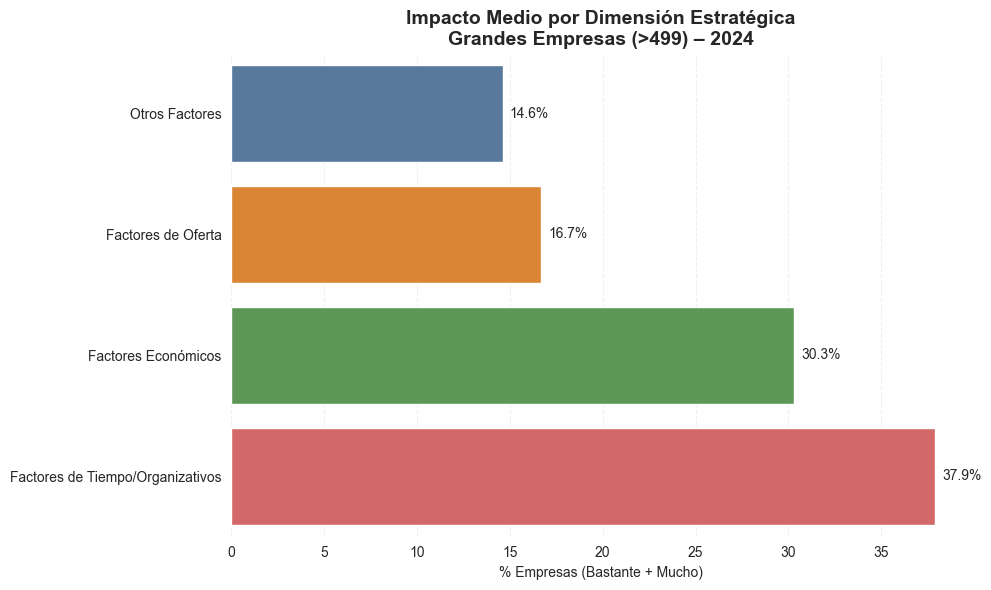

In [128]:
sns.set_style("white")

plt.figure(figsize=(10,6), facecolor="none")

resumen_plot = resumen_estrategico.sort_values('RELEVANCIA', ascending=True)

ax = sns.barplot(
    data=resumen_plot,
    x='RELEVANCIA',
    y='dimension',
    palette=['#4C78A8', '#F58518', '#54A24B', '#E45756']
)

plt.title('Impacto Medio por Dimensión Estratégica\nGrandes Empresas (>499) – 2024', fontsize=14, weight='bold')
plt.xlabel('% Empresas (Bastante + Mucho)')
plt.ylabel('')


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

ax.set_facecolor('none')

sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- El principal problema no es económico ni externo, sino operativo interno: falta de tiempo y organización para formar.
- El dinero importa, pero no es el principal freno. El problema es más de gestión y aprovechamiento de recursos que de falta de presupuesto.
- El mercado formativo no es el principal problema. La oferta existe, el bloqueo está dentro de las empresas.


La relevancia de los factores de tiempo y organización queda reforzada por el contraste estadístico realizado sobre las barreras individuales que integran esta dimensión, donde se observan incrementos significativos entre 2020 y 2024.

## 3. Visualización de la Evolución Temporal (Líneas 2020-2024) y cálculo de Variación Relativa.


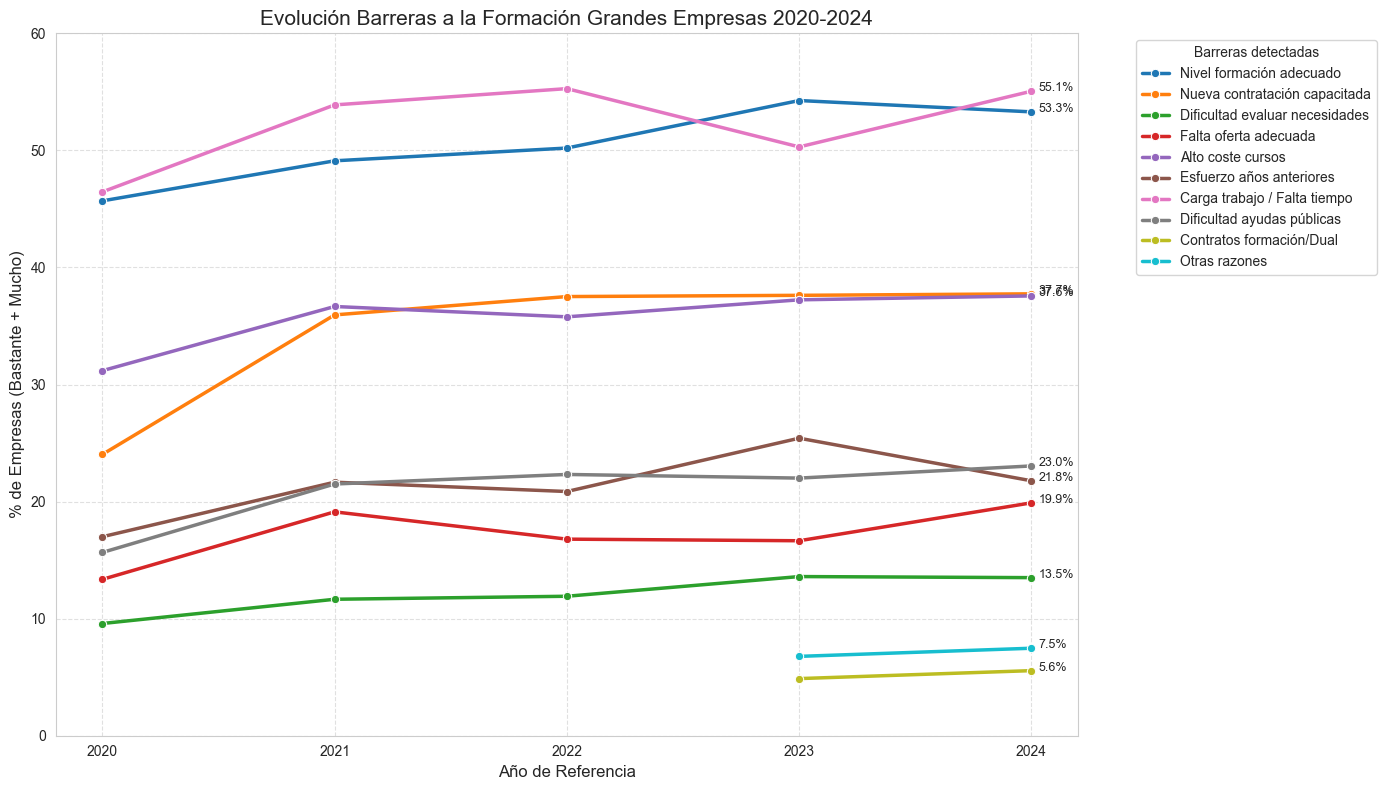

In [137]:
# 1. Filtramos por el segmento de grandes empresas que forman (EAL-24c)
df_lineas = df_relevancia[
    df_relevancia['tabla'] == 'EAL-24c'
].copy()

# 2. Configuración
plt.figure(figsize=(14, 8), facecolor='none')
sns.set_style("whitegrid")

# 3. Gráfico
ax = sns.lineplot(
    data=df_lineas,
    x='anio',
    y='RELEVANCIA',
    hue='ambito_corto',
    marker='o',
    linewidth=2.5
)

ax.set_facecolor('none')

# 4. Etiquetas solo para 2024
df_2024 = df_lineas[df_lineas['anio'] == 2024]

for _, row in df_2024.iterrows():
    ax.text(
        row['anio'] + 0.03,
        row['RELEVANCIA'],
        f"{row['RELEVANCIA']:.1f}%",
        fontsize=9
    )

# 5. Formato
plt.title(
    'Evolución Barreras a la Formación Grandes Empresas 2020-2024',
    fontsize=15
)

plt.ylabel('% de Empresas (Bastante + Mucho)', fontsize=12)
plt.xlabel('Año de Referencia', fontsize=12)

# SOLO años enteros
plt.xticks([2020, 2021, 2022, 2023, 2024])

# Escala fija
plt.ylim(0, 60)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Barreras detectadas'
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

El contraste estadístico entre 2020 y 2024 muestra que la mayoría de barreras históricas presentan incrementos significativos.

Destacan especialmente la carga de trabajo/falta de tiempo (+8.6 pp), la nueva contratación capacitada (+13.7 pp) y la percepción de nivel de formación adecuado (+7.6 pp), lo que indica un aumento generalizado de los obstáculos percibidos para la formación en las grandes empresas.

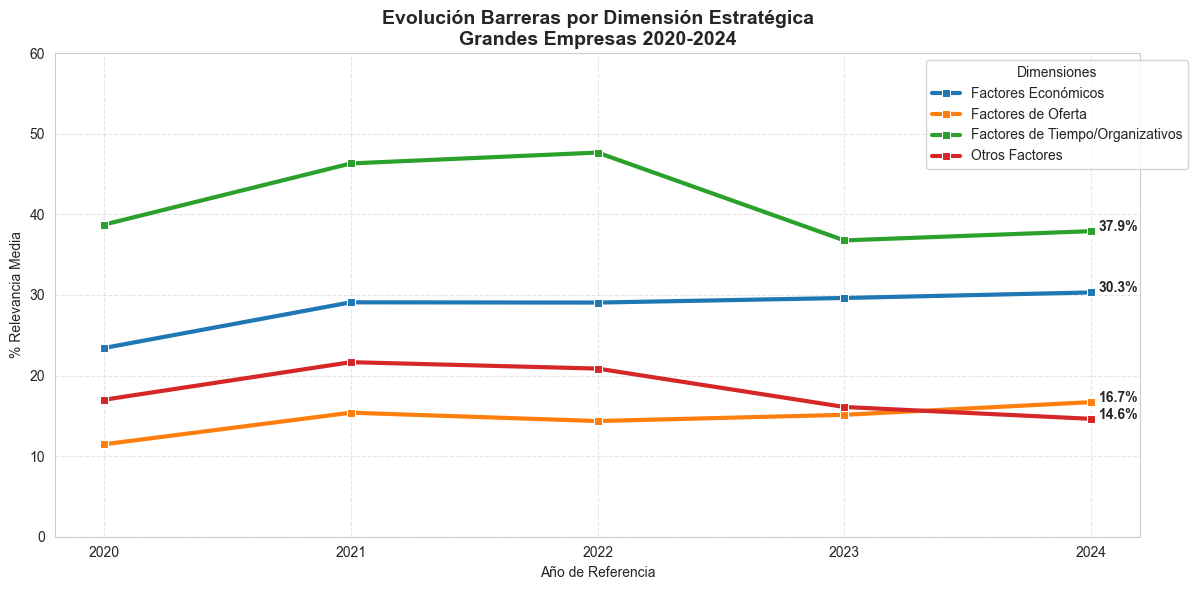

In [139]:
#Calculamos la RELEVANCIA media por dimensión y año
df_evolucion_dim = (
    df_relevancia[df_relevancia['tabla'] == 'EAL-24c']
    .groupby(['anio', 'dimension'])['RELEVANCIA']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6), facecolor='none')
sns.set_style("whitegrid")

ax = sns.lineplot(
    data=df_evolucion_dim,
    x='anio',
    y='RELEVANCIA',
    hue='dimension',
    marker='s',
    linewidth=3
)

ax.set_facecolor('none')

# Etiquetas solo en 2024
df_2024 = df_evolucion_dim[df_evolucion_dim['anio'] == 2024]

for _, row in df_2024.iterrows():
    ax.text(
        row['anio'] + 0.03,
        row['RELEVANCIA'],
        f"{row['RELEVANCIA']:.1f}%",
        fontsize=10,
        weight='bold'
    )

plt.title(
    'Evolución Barreras por Dimensión Estratégica\nGrandes Empresas 2020-2024',
    fontsize=14,
    weight='bold'
)

plt.ylabel('% Relevancia Media')
plt.xlabel('Año de Referencia')

plt.xticks([2020, 2021, 2022, 2023, 2024])

plt.ylim(0, 60)

plt.legend(
    title='Dimensiones',
    bbox_to_anchor=(1.05, 1)
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Factores de Tiempo/Organizativos** → dimensión dominante (~38%)

  * Principal freno estructural
  * Relacionado con carga de trabajo y organización interna

**Factores Económicos** → segundo bloque (~30%)

  * Costes y ayudas públicas
  * Estables en los últimos años

**Factores de Oferta** → menor impacto (~17%)

  * Indica que la oferta formativa no es el principal problema

**Otros factores** → peso reducido (~15%)

  * Influencia decreciente tras la pandemia


#### Preparación y Armonización (El "Año Base")
Hay cambios estructurales entre los años del df, es decir hay tablas que no existen en ciertos años. No podemos usar 2020 como año base para todo. Usaremos esta lógica:
- Barreras históricas → test 2020 vs 2024.
- Barreras nuevas (Contratos formación/Dual y Otras razones) → test 2023 vs 2024.
- COVID → fuera del análisis de tendencias porque desaparece antes de 2024.

**Objetivo:** Identificar qué barreras están creciendo más rápido porcentualmente, lo que indicará problemas emergentes para RapidExpress.

In [ ]:
#Filtramos por el segmento RapidExpress (>499 y formación SI)
df_tendencia = df_relevancia[(df_relevancia['tabla'] == 'EAL-24c')].copy()

In [ ]:
#Calculamos Variación Relativa (%) entre el primer año disponible y el último año
def calcular_var_relativa(group):
    '''
    La variación relativa se calcula entre el primer año disponible y el último año disponible para cada barrera.
    Esto permite incluir categorías incorporadas posteriormente (ej. Contratos formación/Dual)
    '''
    group = group.sort_values('anio')

    val_inicial = group['RELEVANCIA'].iloc[0]
    val_final = group['RELEVANCIA'].iloc[-1]

    #Evita la división por cero
    if val_inicial == 0:
        return None

    return ((val_final - val_inicial) / val_inicial) * 100

In [ ]:
resumen_tendencia = (
    df_tendencia
    .groupby('ambito_corto')
    .apply(calcular_var_relativa)
    .reset_index(name='Variacion_Relativa_%')
)

#Ordenamos de mayor crecimiento a mayor caída
resumen_tendencia = resumen_tendencia.sort_values(
    by='Variacion_Relativa_%',
    ascending=False
)

print(resumen_tendencia)

                     ambito_corto  Variacion_Relativa_%
8   Nueva contratación capacitada             57.115505
6           Falta oferta adecuada             48.970423
3      Dificultad ayudas públicas             47.211753
4  Dificultad evaluar necesidades             40.901503
5        Esfuerzo años anteriores             28.116726
0               Alto coste cursos             20.486178
1    Carga trabajo / Falta tiempo             18.517243
7        Nivel formación adecuado             16.643684
2        Contratos formación/Dual             13.934426
9                   Otras razones             10.268516


/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42355/3257221976.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_var_relativa)


#### Pruebas de visualización

##### Prueba 1

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_42355/3347187375.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


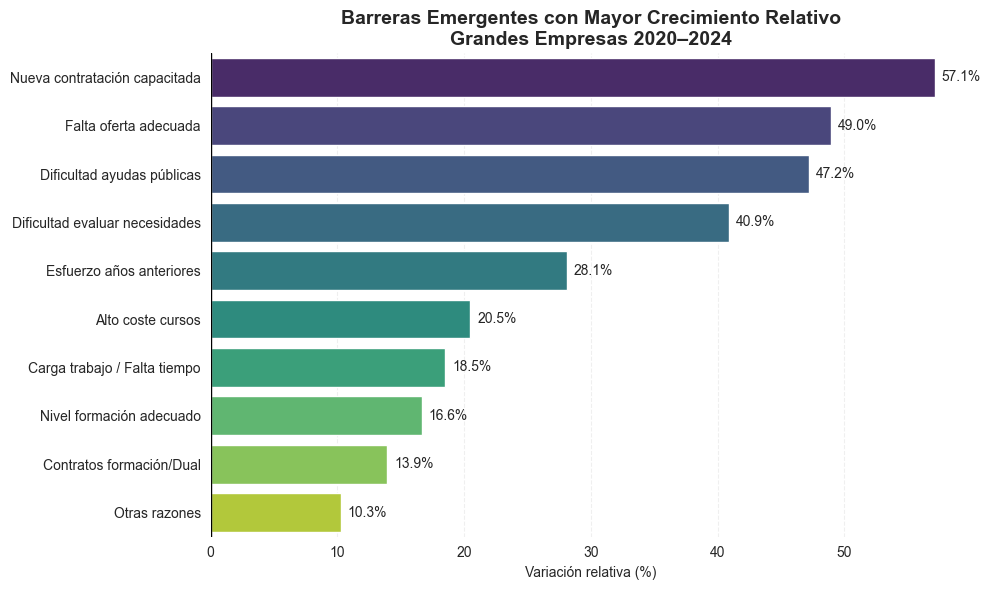

In [135]:
sns.set_style("white")


plot_df = resumen_tendencia.dropna().sort_values(
    'Variacion_Relativa_%',
    ascending=False
)


plt.figure(figsize=(10,6), facecolor='none')

ax = sns.barplot(
    data=plot_df,
    x='Variacion_Relativa_%',
    y='ambito_corto',
    palette='viridis'
)

plt.axvline(0, color='black', linewidth=1)


plt.title('Barreras Emergentes con Mayor Crecimiento Relativo\nGrandes Empresas 2020–2024', fontsize=14, weight='bold')

plt.xlabel('Variación relativa (%)')
plt.ylabel('')


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

ax.set_facecolor('none')


sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##### Prueba 2

Guardamos la relevancia 2024 en un dataframe para mostrarlo en barras agrupadas con la varianza relativa

In [ ]:
relevancia_2024 = (
    df_tendencia[df_tendencia['anio'] == 2024]
    [['ambito_corto', 'RELEVANCIA']]
    .rename(columns={'RELEVANCIA': 'Relevancia_2024'})
)

plot_df = (
    resumen_tendencia
    .merge(relevancia_2024, on='ambito_corto')
    .dropna()
)

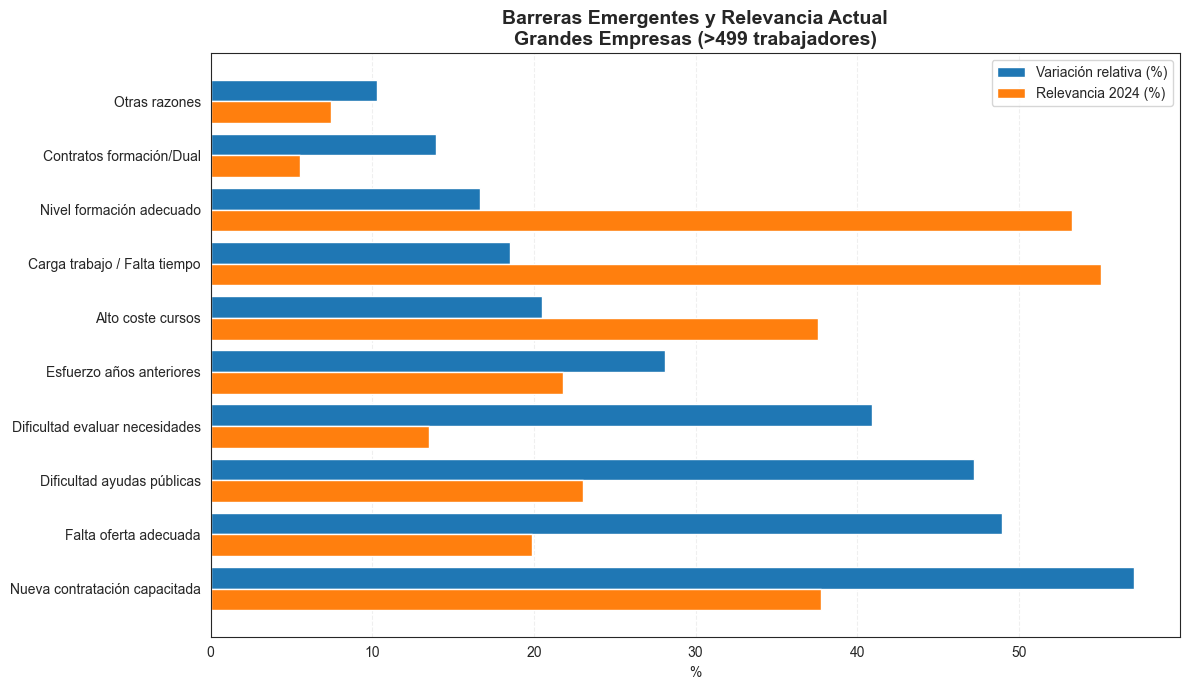

In [ ]:
plot_df = plot_df.sort_values(
    'Variacion_Relativa_%',
    ascending=False
)

fig, ax = plt.subplots(figsize=(12,7), facecolor='none')

y = np.arange(len(plot_df))
altura = 0.4

ax.barh(
    y + altura/2,
    plot_df['Variacion_Relativa_%'],
    height=altura,
    label='Variación relativa (%)'
)

ax.barh(
    y - altura/2,
    plot_df['Relevancia_2024'],
    height=altura,
    label='Relevancia 2024 (%)'
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df['ambito_corto'])

ax.set_title(
    'Barreras Emergentes y Relevancia Actual\nGrandes Empresas (>499 trabajadores)',
    fontsize=14,
    weight='bold'
)

ax.set_xlabel('%')
ax.set_ylabel('')

ax.legend()

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##### Prueba 3

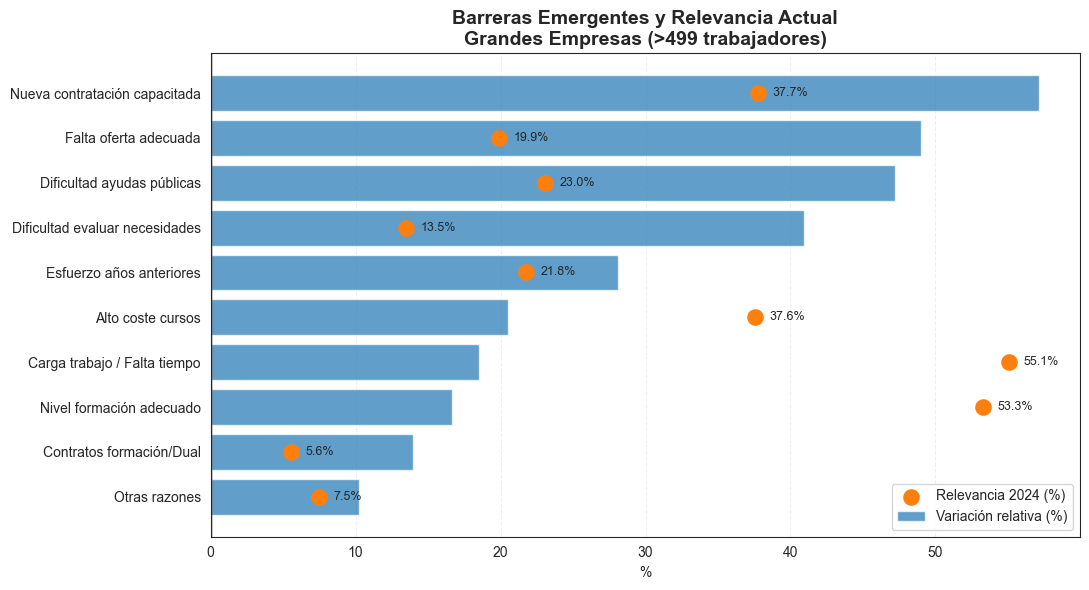

In [ ]:
# Relevancia en 2024
relevancia_2024 = (
    df_tendencia[df_tendencia['anio'] == 2024]
    [['ambito_corto', 'RELEVANCIA']]
    .rename(columns={'RELEVANCIA': 'Relevancia_2024'})
)

# Unimos con la variación relativa
plot_df = (
    resumen_tendencia
    .merge(relevancia_2024, on='ambito_corto')
    .sort_values('Variacion_Relativa_%', ascending=True)
)

sns.set_style("white")

fig, ax = plt.subplots(figsize=(11, 6), facecolor='none')

# Barras = crecimiento
ax.barh(
    plot_df['ambito_corto'],
    plot_df['Variacion_Relativa_%'],
    alpha=0.7,
    label='Variación relativa (%)'
)

# Puntos = relevancia actual
ax.scatter(
    plot_df['Relevancia_2024'],
    plot_df['ambito_corto'],
    s=120,
    zorder=3,
    label='Relevancia 2024 (%)'
)

# Etiquetas de los puntos
for _, row in plot_df.iterrows():
    ax.text(
        row['Relevancia_2024'] + 1,
        row['ambito_corto'],
        f"{row['Relevancia_2024']:.1f}%",
        va='center',
        fontsize=9
    )

ax.axvline(0, color='black', linewidth=1)

plt.title(
    'Barreras Emergentes y Relevancia Actual\nGrandes Empresas (>499 trabajadores)',
    fontsize=14,
    weight='bold'
)

plt.xlabel('%')
plt.ylabel('')

ax.legend()

plt.grid(axis='x', linestyle='--', alpha=0.3)

ax.set_facecolor('none')

plt.tight_layout()
plt.show()

La nueva contratación capacitada presenta el mayor crecimiento relativo (+57.1%) y también un incremento estadísticamente significativo respecto a 2020. Pero carga trabajo y nivel formación adecuado siguen siendo las barreras mas relevantes

#### Validación Estadistica

No tenemos microdatos y trabajaamos con porcentajes publicados. Por tanto el Z-test es: una aproximación basada en los tamaños muestrales reportados en el informe metodologico estandarizado del EAL.

In [ ]:
df_relevancia[
    (df_relevancia['tabla']=='EAL-24c')
].groupby('anio')['ambito_corto'].count()

anio
2020     8
2021     8
2022     8
2023    10
2024    10
Name: ambito_corto, dtype: int64

In [ ]:
eal24_2022 = set(
    df_relevancia[
        (df_relevancia['tabla'] == 'EAL-24c') &
        (df_relevancia['anio'] == 2022)
    ]['ambito_corto']
)

eal24_2023 = set(
    df_relevancia[
        (df_relevancia['tabla'] == 'EAL-24c') &
        (df_relevancia['anio'] == 2023)
    ]['ambito_corto']
)

print("Solo en 2022:")
print(sorted(eal24_2022 - eal24_2023))

print("\nSolo en 2023:")
print(sorted(eal24_2023 - eal24_2022))

Solo en 2022:
[]

Solo en 2023:
['Contratos formación/Dual', 'Otras razones']


In [ ]:
eal24_2023 = set(
    df_relevancia[
        (df_relevancia['tabla'] == 'EAL-24c') &
        (df_relevancia['anio'] == 2023)
    ]['ambito_corto']
)

eal24_2024 = set(
    df_relevancia[
        (df_relevancia['tabla'] == 'EAL-24c') &
        (df_relevancia['anio'] == 2024)
    ]['ambito_corto']
)

print("Solo en 2023:")
print(sorted(eal24_2024 - eal24_2023))

print("\nSolo en 2024:")
print(sorted(eal24_2023 - eal24_2024))

Solo en 2023:
[]

Solo en 2024:
[]


In [ ]:
#Parámetros de muestra (Fuente: Informe Metodológico Estandarizado)
n_2021 = 1471
n_2024 = 1992
n_2020 = 1595
n_2023 = 1878
n_2024 = 1992

In [ ]:
df_val_tendencia = df_relevancia[
    df_relevancia['tabla'] == 'EAL-24c'
].copy()

barreras_nuevas = [
    'Contratos formación/Dual',
    'Otras razones'
]

resultados_tendencia = []

In [ ]:
for b in df_val_tendencia['ambito_corto'].unique():

    # Selección automática del año base
    if b in barreras_nuevas:
        anio_base = 2023
        n_base = n_2023
    else:
        anio_base = 2020
        n_base = n_2020

    val_base = df_val_tendencia[
        (df_val_tendencia['ambito_corto'] == b) &
        (df_val_tendencia['anio'] == anio_base)
    ]['RELEVANCIA']

    val_2024 = df_val_tendencia[
        (df_val_tendencia['ambito_corto'] == b) &
        (df_val_tendencia['anio'] == 2024)
    ]['RELEVANCIA']

    if not val_base.empty and not val_2024.empty:

        p_base = float(val_base.iloc[0])
        p_2024 = float(val_2024.iloc[0])

        count = [
            round(p_2024 * n_2024 / 100),
            round(p_base * n_base / 100)
        ]

        nobs = [n_2024, n_base]

        stat, p_value = proportions_ztest(
            count,
            nobs
        )

        resultados_tendencia.append({
            'Barrera': b,
            'Año Base': anio_base,
            'Relevancia Base (%)': round(p_base, 2),
            'Relevancia 2024 (%)': round(p_2024, 2),
            'Variación Absoluta (pp)': round(p_2024 - p_base, 2),
            'p-valor': round(p_value, 4),
            '¿Cambio Real (p<0.05)?':
                'SÍ' if p_value < 0.05 else 'NO'
        })

df_test_tendencia = (
    pd.DataFrame(resultados_tendencia)
    .sort_values('p-valor')
)

print(
    "--- VALIDACIÓN DE TENDENCIAS GRANDES EMPRESAS (>499) ---"
)

print(df_test_tendencia)

--- VALIDACIÓN DE TENDENCIAS GRANDES EMPRESAS (>499) ---
                          Barrera  Año Base  Relevancia Base (%)  \
0        Nivel formación adecuado      2020                45.69   
1   Nueva contratación capacitada      2020                24.02   
3           Falta oferta adecuada      2020                13.36   
6    Carga trabajo / Falta tiempo      2020                46.45   
7      Dificultad ayudas públicas      2020                15.66   
4               Alto coste cursos      2020                31.18   
2  Dificultad evaluar necesidades      2020                 9.58   
5        Esfuerzo años anteriores      2020                17.00   
8        Contratos formación/Dual      2023                 4.88   
9                   Otras razones      2023                 6.78   

   Relevancia 2024 (%)  Variación Absoluta (pp)  p-valor  \
0                53.29                     7.60   0.0000   
1                37.75                    13.72   0.0000   
3             

El análisis evidencia un incremento significativo de la mayoría de barreras a la formación entre 2020 y 2024. Las barreras relacionadas con la carga de trabajo, la percepción de suficiencia formativa y la preferencia por incorporar personal ya capacitado son las que muestran una evolución más relevante, reforzando la idea de que los obstáculos a la formación son principalmente internos y organizativos.

### 4. Benchmarking Estadístico y Tests de Diferencias
Este es el punto donde aplicas el rigor solicitado por tu jefa utilizando el cierre de 2024 como foto actual:
*   **Z-test de Proporciones:** Compararás la relevancia en empresas de **>499 trabajadores** (EAL-24c) frente al **Sector Servicios** (EAL-24f).
*   **Interpretación Crítica:** Solo considerarás como "Práctica Diferencial" de las grandes empresas aquellos ámbitos donde el **p-valor sea < 0.05**. Por ejemplo, ya sabemos que el "Nivel de formación apropiado" tiene una diferencia significativa de **-17.89 puntos** respecto al sector, confirmando que las grandes empresas son más exigentes con sus competencias.

In [ ]:
#Filtramos solo para el año 2024 para el benchmarking
df_2024 = df_relevancia[df_relevancia['anio'] == 2024]


In [ ]:
sns.set_style("white")

comparativa_2024 = df_2024[
    df_2024['tabla'].isin(['EAL-24f', 'EAL-24c'])
].pivot(
    index='ambito_corto', 
    columns='tabla', 
    values='RELEVANCIA'
)

comparativa_2024['Diferencia_pp'] = (
    comparativa_2024['EAL-24c'] - comparativa_2024['EAL-24f']
)

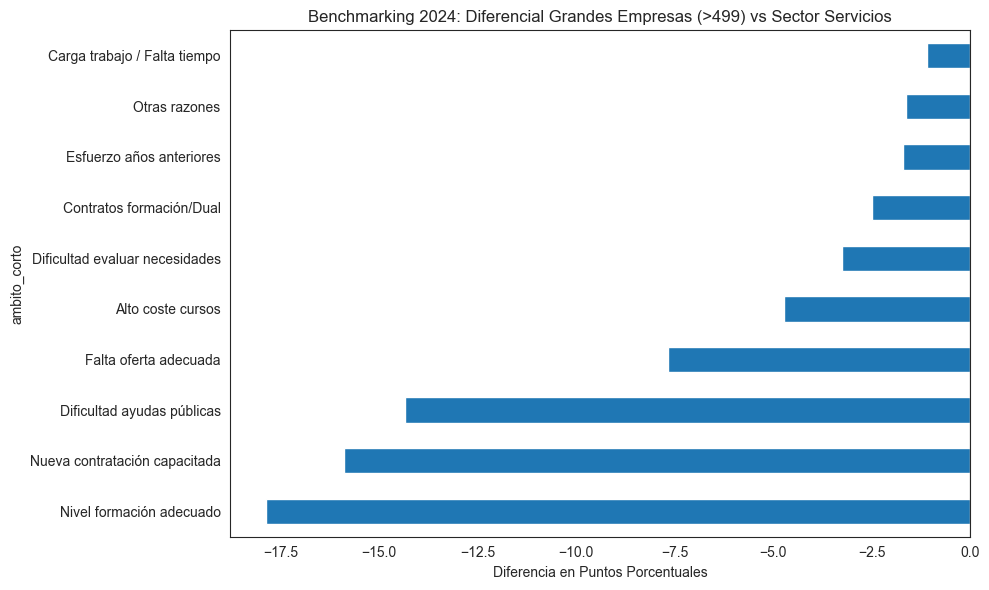

In [ ]:
fig, ax = plt.subplots(figsize=(10,6), facecolor='none')
ax.set_facecolor('none')

comparativa_2024['Diferencia_pp'].sort_values().plot(
    kind='barh', 
    ax=ax
)

plt.title('Benchmarking 2024: Diferencial Grandes Empresas (>499) vs Sector Servicios')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Diferencia en Puntos Porcentuales')

plt.tight_layout()
plt.show()

> El análisis comparativo muestra que las empresas de más de 499 trabajadores perciben **menos barreras para la formación que la media de servicios**. Sin embargo, también son **menos propensas a considerar que el nivel formativo de su plantilla ya es suficiente**, lo que sugiere una mayor orientación hacia el desarrollo continuo de competencias y una mayor exigencia en materia de formación.

#### Validación Estadistica

Basándonos en el Informe Metodológico, los tamaños de muestra (n) para el año 2024 son:
- Grandes Empresas (>499 trabajadores): n=1.992 empresas.
- Sector Servicios (Total): n=5.963 empresas (suma de los subsectores G a S del informe).

In [ ]:
# 1. Parámetros de muestra para 2024
n_499 = 1992
n_servicios = 5963

# 2. Filtramos solo 2024
df_2024 = df_relevancia[df_relevancia['anio'] == 2024].copy()

barreras = (
    df_2024[df_2024['tabla'] == 'EAL-24c']['ambito_corto']
    .unique()
)

resultados = []

for barrera in barreras:

    fila_499 = df_2024[
        (df_2024['tabla'] == 'EAL-24c') &
        (df_2024['ambito_corto'] == barrera)
    ]

    fila_servicios = df_2024[
        (df_2024['tabla'] == 'EAL-24f') &
        (df_2024['ambito_corto'] == barrera)
    ]

    # Saltamos si falta alguna observación
    if fila_499.empty or fila_servicios.empty:
        continue

    # Extraemos valores escalares
    p1 = float(fila_499['RELEVANCIA'].iloc[0])
    p2 = float(fila_servicios['RELEVANCIA'].iloc[0])

    # Conversión a frecuencias absolutas
    count = [
        round(p1 * n_499 / 100),
        round(p2 * n_servicios / 100)
    ]

    nobs = [n_499, n_servicios]

    # Z-test de proporciones
    stat, p_value = proportions_ztest(count, nobs)

    resultados.append({
        'Barrera': barrera,
        'Relevancia >499 (%)': round(p1, 2),
        'Relevancia Servicios (%)': round(p2, 2),
        'Diferencia (pp)': round(p1 - p2, 2),
        'p-valor': round(p_value, 4),
        'Significativa (p<0.05)': 'SÍ' if p_value < 0.05 else 'NO'
    })

# 3. Resultados
df_ztest = pd.DataFrame(resultados)

df_ztest = df_ztest.sort_values(
    by='Diferencia (pp)',
    key=lambda x: abs(x),
    ascending=False
)

print("\n--- VALIDACIÓN ESTADÍSTICA: GRANDES EMPRESAS VS SECTOR SERVICIOS (2024) ---\n")
print(df_ztest)


--- VALIDACIÓN ESTADÍSTICA: GRANDES EMPRESAS VS SECTOR SERVICIOS (2024) ---

                          Barrera  Relevancia >499 (%)  \
0        Nivel formación adecuado                53.29   
1   Nueva contratación capacitada                37.75   
8      Dificultad ayudas públicas                23.05   
3           Falta oferta adecuada                19.89   
4               Alto coste cursos                37.57   
2  Dificultad evaluar necesidades                13.50   
5        Contratos formación/Dual                 5.56   
6        Esfuerzo años anteriores                21.78   
9                   Otras razones                 7.47   
7    Carga trabajo / Falta tiempo                55.06   

   Relevancia Servicios (%)  Diferencia (pp)  p-valor Significativa (p<0.05)  
0                     71.18           -17.89   0.0000                     SÍ  
1                     53.63           -15.88   0.0000                     SÍ  
8                     37.40           -14.35  

In [ ]:
df_relevancia[
    df_relevancia['ambito_corto']
    .str.contains("COVID", case=False, na=False)
][['anio','ambito_corto','RELEVANCIA']]

,anio,ambito_corto,RELEVANCIA
165,2021,Restricciones COVID,26.003
176,2021,Restricciones COVID,28.111
187,2021,Restricciones COVID,27.761
198,2022,Restricciones COVID,12.942
209,2022,Restricciones COVID,20.265
220,2022,Restricciones COVID,12.850


Los resultados muestran que, en la mayoría de las barreras analizadas, existen diferencias estadísticamente significativas entre las grandes empresas formadoras (>499 empleados) y el conjunto formador del sector servicios, lo que indica que ambos grupos no perciben los obstáculos a la formación de la misma manera.

"Nivel de formación apropiado" tiene un p-valor de 0.0000 --> Las grandes empresas muestran una menor percepción de suficiencia formativa, lo que podría reflejar una mayor orientación hacia el aprendizaje continuo que las empresas más pequeñas de servicios.

## HALLAZGOS

#### 1. Principal barrera Empresas grandes: tiempo y organización (37.9%)

El mayor freno a la formación no es económico ni externo, sino operativo interno.

Implicación clave:
La solución no requiere más presupuesto, sino reorganizar la planificación del trabajo, aprovechando ventanas de baja actividad para poder formar sin afectar la productividad.

---

#### 2. Riesgo emergente Empresas Grandes: percepción de “formación suficiente”

Aumenta significativamente la idea de que el personal ya está capacitado.

Implicación clave:
Existe riesgo de estancamiento formativo, por lo que es necesario realizar análisis periódicos de brechas de competencias para evitar pérdida de competitividad.

---

#### 3. Posición competitiva favorable

Las grandes empresas presentan menos barreras que el sector servicios en general.

Implicación clave:
RapidExpress está en una posición ventajosa, especialmente en la gestión de ayudas y formación, lo que puede traducirse en eficiencia y atracción de talento.

---

#### 4. Oferta formativa no es el problema

El mercado parece suficiente y estable (16.7%) para empresas grandes. Los resultados sugieren que la oferta formativa disponible no constituye la principal barrera para las grandes empresas

Implicación clave:
No es necesario buscar más proveedores, sino optimizar el uso del tiempo interno para aprovechar la oferta existente.

---

### Conclusión global

El principal desafío de RapidExpress no es externo ni financiero, sino organizativo y de gestión del tiempo, con un riesgo emergente de estancamiento por exceso de confianza en la capacitación actual.
